# Week 5: Unsupervised Learning — Clustering

**Intern:** Fiza Zahid Ali  
**Discipline:** Bachelor of Science in Artificial Intelligence (BSAI)  
**Organization:** Zynxis  
**Task:** Unsupervised Learning — Clustering

## 1. Project Objective

The objective of this task is to apply unsupervised learning techniques to discover hidden patterns and groups within a dataset.

The Iris dataset is used to demonstrate clustering techniques.

The following algorithms are implemented:

1. K-Means Clustering
2. DBSCAN Clustering

The Elbow Method is used to estimate the optimal number of clusters for K-Means.

Principal Component Analysis (PCA) is then used to reduce the dataset to two dimensions for visualization.

Finally, the discovered clusters are analyzed and a potential use case for Zynxis is suggested.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
df.shape

(150, 4)

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

## 2. Dataset Overview

The Iris dataset contains 150 observations and four numerical features describing iris flowers:

- Sepal length
- Sepal width
- Petal length
- Petal width

Since this is an unsupervised learning task, the original species labels are not used during clustering. The algorithms are allowed to discover groups based only on the feature values.

In [6]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)
X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

## 3. K-Means Clustering

K-Means is an unsupervised learning algorithm that divides observations into a predefined number of clusters.

The algorithm assigns each observation to the nearest cluster center and repeatedly updates the centers until the clusters stabilize.

The optimal number of clusters will first be investigated using the Elbow Method.

In [9]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

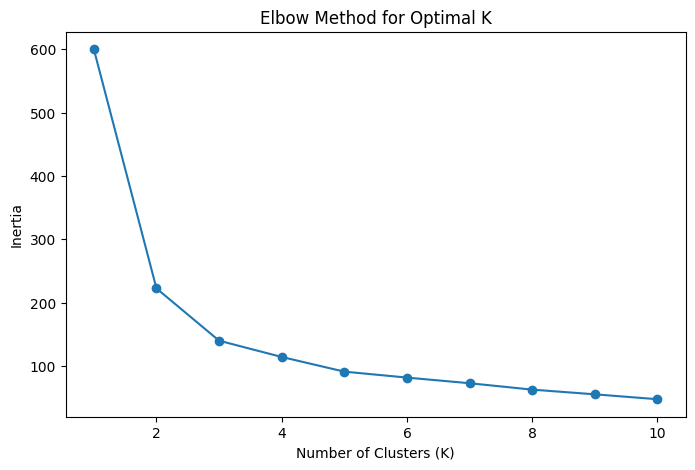

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method for Optimal K")

plt.show()

In [13]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)
df["KMeans_Cluster"] = kmeans_labels

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),KMeans_Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [14]:
df["KMeans_Cluster"].value_counts().sort_index()

,count
KMeans_Cluster,
0,53
1,50
2,47


In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(150, 2)

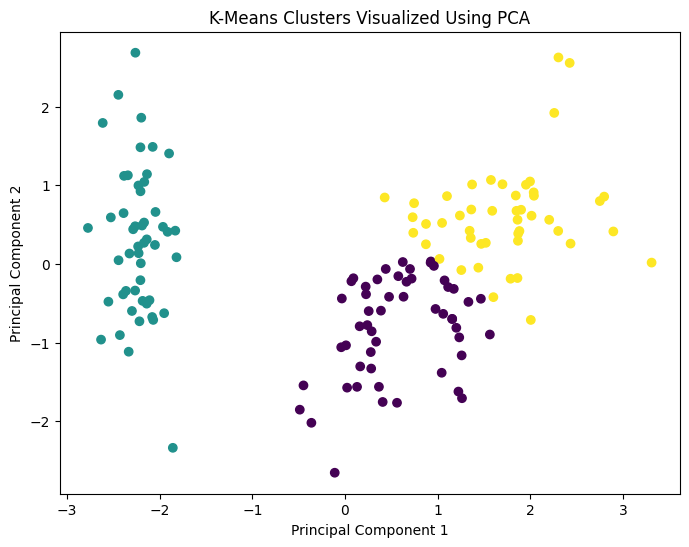

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Clusters Visualized Using PCA")
plt.savefig(
    "kmeans_clusters_pca.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 4. DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm.

Unlike K-Means, DBSCAN does not require the number of clusters to be specified in advance.

It groups observations that are closely packed together and can identify observations that do not belong to any dense group as noise.

In [18]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

In [19]:
df["DBSCAN_Cluster"] = dbscan_labels

In [20]:
df["DBSCAN_Cluster"].value_counts().sort_index()

,count
DBSCAN_Cluster,
-1,4
0,49
1,97


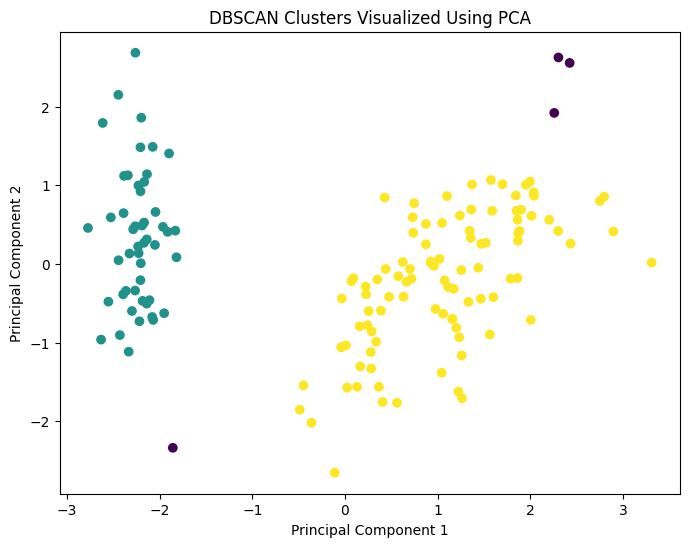

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("DBSCAN Clusters Visualized Using PCA")
plt.savefig(
    "dbscan_clusters_pca.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [24]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.72962445 0.22850762]

Total explained variance:
0.9581320720000166


## 5. Potential Use Case for Zynxis

Clustering could be used by Zynxis to identify groups of interns or candidates with similar characteristics.

For example, Zynxis could collect features such as:

- Technical assessment scores
- Attendance percentage
- Task completion rate
- Project performance
- Communication scores
- Learning progress

A clustering algorithm could automatically group interns into segments such as high-performing, developing, and support-needed groups.

These groups could help Zynxis identify different learning needs and provide more personalized mentorship, training, and performance support.

The main advantage of clustering is that these groups can be discovered from the data without requiring predefined labels.

## 6. Conclusion

In this task, two unsupervised learning algorithms, K-Means and DBSCAN, were applied to the Iris dataset.

The Elbow Method was used to investigate a suitable number of clusters for K-Means, while PCA was used to reduce the four-dimensional feature space to two dimensions for visualization.

The clustering results demonstrated how unsupervised learning can discover hidden patterns in data without requiring predefined target labels.

This task provided practical experience with clustering, dimensionality reduction, visualization, and the potential application of unsupervised learning in real-world organizational scenarios.